# 3. Multiple Linear Regression

Linear Model for $M$ Predictors

$$
\begin{split}
Y & = \theta_0 + \theta_1 X_1 + \theta_2 X_2 + \cdots + \theta_M X_M \\
& = \sum_{i=1}^N \theta_0 + \sum_{j=1}^Mx_{ij}\theta_j
\end{split}
$$

The goal is to obtain the best estimation of the parameters $\theta_0$, $\theta_1$, $\dots$, $\theta_M$, denoted as $\hat{\theta}_0$, $\hat{\theta}_1$, $\dots$, $\hat{\theta}_M$. With these parameters, we can compute $\hat{f}(X)$ and make predictions about $Y$, represented by $\hat{Y} = \hat{f}(X)$.

If we have $N$ training data available, we can model these data linearly through the matrix relationship:

$$Y = X \boldsymbol{\theta}$$

where:

$$ Y =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N \\
\end{bmatrix}, \,
X =
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1M}\\
1 & x_{11} & \cdots & x_{1M} \\
\vdots & \vdots &  & \vdots \\
1 & x_{N1} & \cdots & x_{NM}\\
\end{bmatrix}, \,
\boldsymbol{\theta} =
\begin{bmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_M \\
\end{bmatrix}
$$

This matrix approach simplifies computation and allows us to efficiently find optimal values for the model parameters.

## 3.1. Cuadrados Mínimos Ordinarios

**Residual Sum of Squares (RSS)**

$$
\mathbf{e} =
\begin{bmatrix}
e_1 \\
e_2 \\
\vdots \\
e_n \\
\end{bmatrix}
$$

$$
\begin{split}
\Rightarrow RSS & = \mathbf{e}^T \mathbf{e} = (Y - X \boldsymbol{\theta})^T(Y - X \boldsymbol{\theta}) \\
& = Y^TY - \boldsymbol{\theta}^TX^TY - Y^TX\boldsymbol{\theta} + \boldsymbol{\theta}^TX^TX \boldsymbol{\theta} \\
& = Y^TY - \left( Y^TX\boldsymbol{\theta} \right)^T - Y^TX\boldsymbol{\theta} + \boldsymbol{\theta}^TX^TX \boldsymbol{\theta} \\
& = Y^TY - 2 Y^TX\boldsymbol{\theta} + \boldsymbol{\theta}^TX^TX\boldsymbol{\theta}, \,\,\,\, \boldsymbol{\theta}^TX^TY\, \text{is scalar} \, (1 \times 1)
\end{split}
$$

**Critical Points**

$$
\begin{split}
\frac{\partial RSS}{\partial \boldsymbol{\theta}} & = \frac{\partial}{\partial \boldsymbol{\theta}} \left( Y^TY \right) - \frac{\partial}{\partial \boldsymbol{\theta}} \left[2 \left(X^TY\right)^T\boldsymbol{\theta}\right] + \frac{\partial}{\partial \boldsymbol{\theta}}\left(\boldsymbol{\theta}^TX^TX\boldsymbol{\theta}\right) \\
& = 0 - 2 X^TY + \left[ X^TX\boldsymbol{\theta} + \left( X^T X \right)^T\boldsymbol{\theta} \right] \\
& = -2 X^TY + 2X^TX\boldsymbol{\theta} \\
\end{split}
$$

**Note** To obtain the equation above we use the following properties:

- Let $A$ $1 \times N$ vector of scalars and $B$ $N \times 1$ vector of scalars. If $C = A^TB$ then $\frac{\partial C}{\partial B} = A$ (remember that the derivative with respect to a vector of a scalar is a vector)
- Let $A$ $N \times N$ matrix and $B$ $N \times 1$ vector of scalars. If $C = B^TAB$ then $\frac{\partial C}{\partial B} = AB + A^TB$ (remember that the derivative with respect to a vector of a scalar is a vector)

Therefore, setting to zero and solving for $\boldsymbol{\theta}$ yields:

$$
\boxed{
\hat{\boldsymbol{\theta}} = (X^TX)^{-1}X^TY
}
$$

## 3.2. Parameter estimation in linear regression by maximum likelihood

While the least squares method is a common choice for estimating $\boldsymbol{\theta}$, an alternative approach is maximum likelihood estimation (MLE). This method aims to estimate the values of $\boldsymbol{\theta}$ under the assumption that $\mathbf{e}$ follows a normal distribution with mean $\boldsymbol{0}$ and variance $\sigma^2\ mathbb{ 1}$ (homoscedasticity). To derive the MLE of $\boldsymbol{\theta}$, we begin by defining the likelihood function which in matrix notation takes the following form:

$$
L(\boldsymbol{\theta},\sigma^2|X) = \prod_{i=1}^N\frac{1}{\sqrt{2\pi\sigma^2}}\mathrm{exp}\left[ \frac{-\left( Y - X \boldsymbol{\theta} \right)^T\left( Y - X \boldsymbol{\theta} \right)}{2\sigma^2} \right]
$$

To simplify calculations it is convenient to maximize the logarithm of the likelihood:

$$
\mathrm{ln}L(\boldsymbol{\theta},\sigma^2|X) = -\frac{N}{2}\mathrm{ln}(2\pi) -\frac{N}{2}\mathrm{ln}(\sigma^2) - \frac{\left( Y - X \boldsymbol{\theta} \right)^T\left( Y - X \boldsymbol{\theta} \right)}{2\sigma^2}
$$

$$
\begin{split}
\frac{\partial \, \mathrm{ln}L(\boldsymbol{\theta},\sigma^2|X)}{\partial \boldsymbol{\theta}} & = \frac{\partial}{\partial \boldsymbol{\theta}} \left[ - \frac{\left( Y - X \boldsymbol{\theta} \right)^T\left( Y - X \boldsymbol{\theta} \right)}{2\sigma^2} \right] \\
& = \frac{\partial}{\partial \boldsymbol{\theta}} \left[ \frac{- Y^TY + 2 \left(X^TY\right)^T\boldsymbol{\theta} - \boldsymbol{\theta}^TX^TX\boldsymbol{\theta}}{2\sigma^2} \right] \\
& = \frac{2X^TY}{2\sigma^2} - \frac{X^TX\boldsymbol{\theta} + \left( X^TX \right)^T\boldsymbol{\theta}}{2\sigma^2} \\
& = \frac{X^TY - X^TX \boldsymbol{\theta}}{\sigma^2} = \boldsymbol{0}
\end{split}
$$

$$
\Rightarrow \boxed{\hat{\boldsymbol{\theta}} = (X^TX)^{-1}X^TY}
$$

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.formula.api import ols

# Avoid code suggestions
import warnings
warnings.filterwarnings("ignore")

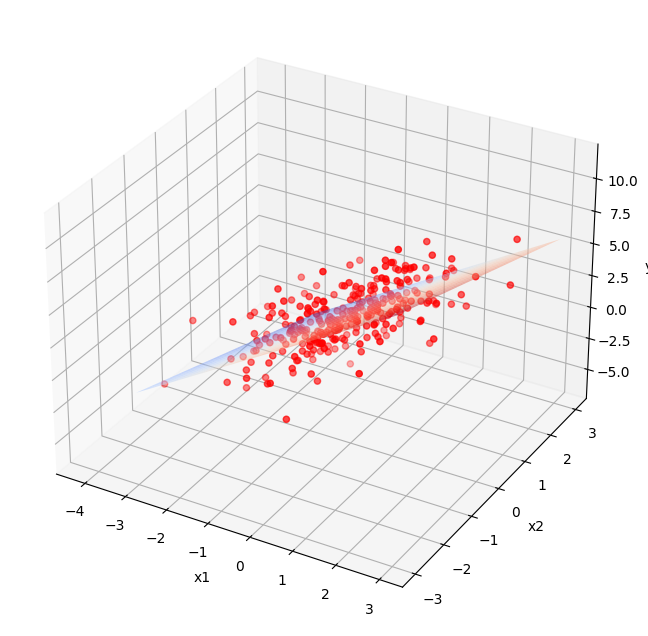

In [2]:
# Data Generation
N = 300
theta_1 = np.random.normal(loc=2, scale=1, size=N)
theta_2 = np.random.normal(loc=-1, scale=1, size=N)
theta_0 = np.random.randn(1)
x1 = np.random.randn(N)
x2 = np.random.randn(N)
y = theta_1 * x1 + theta_2 * x2 + theta_0 + np.random.randn(N)

# Create a design matrix with a column of ones for the constant term
X = sm.add_constant(np.column_stack((x1, x2)))

# Create the linear model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Estimated coefficients
theta_0 = model.params[0]
theta_1 = model.params[1]
theta_2 = model.params[2]

# Create mesh for the fitting plane
x1_vals = np.linspace(-3, 3, 20)
x2_vals = np.linspace(-3, 3, 20)
x1_vals, x2_vals = np.meshgrid(x1_vals, x2_vals)
y_vals = theta_1 * x1_vals + theta_2 * x2_vals + theta_0

# 3D Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Data
ax.scatter(x1, x2, y, c='red', marker='o', label='Data')

# Fitting Plane
ax.plot_surface(x1_vals, x2_vals, y_vals, cmap='coolwarm', alpha=0.5, label='Fitting Plane')

# Axis Labels
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')

plt.show()

## 3.3. Confidence intervals

Confidence intervals are crucial in statistical analysis as they provide a range of values within which we can be confident that the true population parameter lies. In linear regression analysis, confidence intervals are utilized to estimate the precision of the coefficients and predictions derived from the model.

### 3.3.1. Residual Standard Error

In order to construct a confidence interval it is necessary to know the dispersion of the random term $\sigma$. However, in general $\sigma$ is not known, but can be estimated from the data. This estimate of $\sigma$ is what is known as the **Residual Standard Error** or $\text{RSE}$ ($\hat{\sigma}$). $\text{RSE}$ is a fundamental measure in regression analysis and quantifies the dispersion of the observed values around the regression line and since said dispersion is given by $\text{RSS}$, under the assumptions of homoscedasticity (constant variance of errors) and independence of errors (uncorrelated), the unbiased estimate of the variance is obtained by dividing the sum of the squared residuals by $(n - M - 1)$, where $N$ is the number of observations and $M$ is the number of predictors (for the case ofsimple liner regression, there would be two degrees of freedom):

$$
\text{RSE} := \sqrt{\frac{\text{RSS}}{N - M - 1}} = \boldsymbol{\hat{\sigma}}
$$


To calculate the standard error let $A = \left(X^TX \right)^{-1}X^T$, then $\boldsymbol{\hat{\theta}} = AY$. Taking into account that the variance-covariance matrix for a random variable $Y$ denoted by $\boldsymbol{\sigma}^2_Y$ is defined as:

$$
\boldsymbol{\sigma}^2_Y = \text{E}\left[ (Y - \mu_Y)(Y - \mu_Y)^T \right]
$$

and the properties:

- $\text{E}\left[A\right] = A$
- $\text{E}\left[\boldsymbol{\hat{\theta}}\right] = \text{E}\left[AY\right] = A\text{E}\left[Y\right] $

where $A$ is a constant matrix, it can easily see that:

$$
\boldsymbol{\sigma}^2_\boldsymbol{\hat{\theta}} = \boldsymbol{\sigma}^2_{AY} = A \boldsymbol{\sigma}^2_Y A^T
$$

Since the components $y_1, y_2, \dots, y_3$ are independent, the variance-convariance matrix is diagonal, that is, $\boldsymbol{\sigma}^2_Y = \sigma^2\mathbb{1}_{N \times N}$. Then,

$$
\begin{split}
\boldsymbol{\sigma}^2_\boldsymbol{\hat{\theta}} & = \left( X^TX \right)^{-1}X^T\sigma^2\mathbb{1}_{N \times N}X\left( X^T X \right)^{-1} \\
& = \sigma^2\left( X^TX \right)^{-1}X^TX\left( X^TX \right)^{-1} \\
& = \sigma^2\left( X^TX \right)^{-1}
\end{split}
$$

So, the standard error of the set of parameters will be given by:

$$
\text{SE}(\hat{\boldsymbol{\theta}}) = \sigma^2(X^TX)^{-1} \sim \text{RSE} \cdot (X^TX)^{-1} = \sqrt{\frac{\text{RSS}}{N - M - 1}} \cdot (X^TX)^{-1}
$$

and this allows me to build **95%** confidence that the parameters are within twice the standard error of the respective parameter.

In [3]:
# Get regression results
results = model.summary()

# Print the table with coefficients, standard errors, and t-values
print(results.tables[1])

# Generate 95% confidence intervals for the coefficients
confidence_intervals = model.conf_int(alpha=0.05)

# Print confidence intervals
print("\n95% Confidence Intervals:")
print(confidence_intervals)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7753      0.098     28.340      0.000       2.583       2.968
x1             1.9151      0.089     21.532      0.000       1.740       2.090
x2            -0.9416      0.103     -9.172      0.000      -1.144      -0.740

95% Confidence Intervals:
[[ 2.5826198   2.96807036]
 [ 1.7400873   2.0901728 ]
 [-1.14362566 -0.73954499]]


## 3.4. Analysis of Variance (ANOVA) to assessing the linear regression model

We can conduct a hypothesis test to evaluate our model:

$$
\left\{
\begin{array}{l}
H_0: \beta_1 = \beta_2 = \cdots = \beta_M = 0 \\
\\
H_1: \text{at least one} \; \beta_j \neq 0
\end{array} \right.
$$

To do this, we perform an $F$-test based on the $F$ statistic:

$$
F = \frac{(\text{TSS} - \text{RSS})/M}{\text{RSS}/(N - M - 1)}
$$

When there is no relationship between the response variable and the predictors, one would expect the $F$ statistic to take a value close to 1. Conversely, if $H_1$ is true, we expect $F$ to be greater than 1. This can be determined using the $\mathrm{p-value}$ and the significance level $\alpha$ (which can be context-dependent, such as $0.03$ or $0.05$).

Sometimes, we want to test that a particular subset $Q$ of the coefficients is zero.

This corresponds to a null hypothesis.

$$H_0: \beta_{M-Q+1} = \beta_{M-Q+2} = \cdots = \beta_M = 0$$

In this case, we find a second model that uses all variables except the last $Q$. Suppose the sum of squared residuals for that model is $\text{RSS}_0$. Then the appropriate $F$ statistic is:

$$F=\frac{(\text{RSS}_0 - \text{RSS})/Q}{\text{RSS}/(N - M - 1)}$$

In [4]:
# Get the F-statistic and p-value for the F-test
f_statistic = model.fvalue
p_value_f = model.f_pvalue

print("F-statistic:", f_statistic)
print("p-value for F-test:", p_value_f)

F-statistic: 268.1818236460566
p-value for F-test: 2.8867007721024355e-67


In [5]:
# Create a DataFrame
data = {'x1': x1, 'x2': x2, 'y': y}
df = pd.DataFrame(data)

# Fit the model
model = ols('y ~ x1 + x2', data=df).fit()

# Perform Fisher's F-tests for each parameter separately
f_test_beta_0 = model.f_test("Intercept = 0")
f_test_beta_1 = model.f_test("x1 = 0")
f_test_beta_2 = model.f_test("x2 = 0")

print("F-test for beta_0:")
print(f_test_beta_0.summary())

print("F-test for beta_1:")
print(f_test_beta_1.summary())

print("F-test for beta_2:")
print(f_test_beta_2.summary())

F-test for beta_0:
<F test: F=803.1552846114854, p=1.9116278297305898e-86, df_denom=297, df_num=1>
F-test for beta_1:
<F test: F=463.6083211070605, p=1.329502227678812e-62, df_denom=297, df_num=1>
F-test for beta_2:
<F test: F=84.11745510911423, p=8.042506721952793e-18, df_denom=297, df_num=1>
